In [5]:
import pandas as pd
import talib
import pynance as pn
import matplotlib.pyplot as plt

# Load NVDA stock data from local CSV
df = pd.read_csv('../data/AAPL.csv')

# Convert 'Date' column to datetime objects and set as index for time-series analysis
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Ensure numeric data types and handle missing values (clean data)
df = df.apply(pd.to_numeric, errors='coerce')
df.dropna(inplace=True)

print(f"Data loaded: {len(df)} rows.")


Data loaded: 3774 rows.


In [6]:
# --- Moving Averages ---
# SMA helps smooth out price action to identify the long-term trend
df['SMA_20'] = talib.SMA(df['Close'], timeperiod=20)
# EMA gives more weight to recent prices, reacting faster to price changes
df['EMA_20'] = talib.EMA(df['Close'], timeperiod=20)

# --- Relative Strength Index (RSI) ---
# Used to identify momentum; values > 70 are 'overbought', < 30 are 'oversold'
df['RSI_14'] = talib.RSI(df['Close'], timeperiod=14)

# --- MACD (Moving Average Convergence Divergence) ---
# Measures the relationship between two EMAs to signal trend reversals
df['MACD'], df['MACD_signal'], df['MACD_hist'] = talib.MACD(
    df['Close'], fastperiod=12, slowperiod=26, signalperiod=9
)

# Note: Indicators create 'NaN' values at the beginning of the dataframe due to lookback periods
df.dropna(inplace=True)


In [7]:
# Calculate daily returns (required for PyNance metrics)
daily_returns = df['Close'].pct_change().dropna()

try:
    sharpe = pn.sharpe_ratio(daily_returns)
except AttributeError:
    # Alternative path for some versions
    sharpe = daily_returns.mean() / daily_returns.std() * (252**0.5) 

print(f"AAPL Sharpe Ratio: {sharpe:.4f}")



AAPL Sharpe Ratio: 1.1504


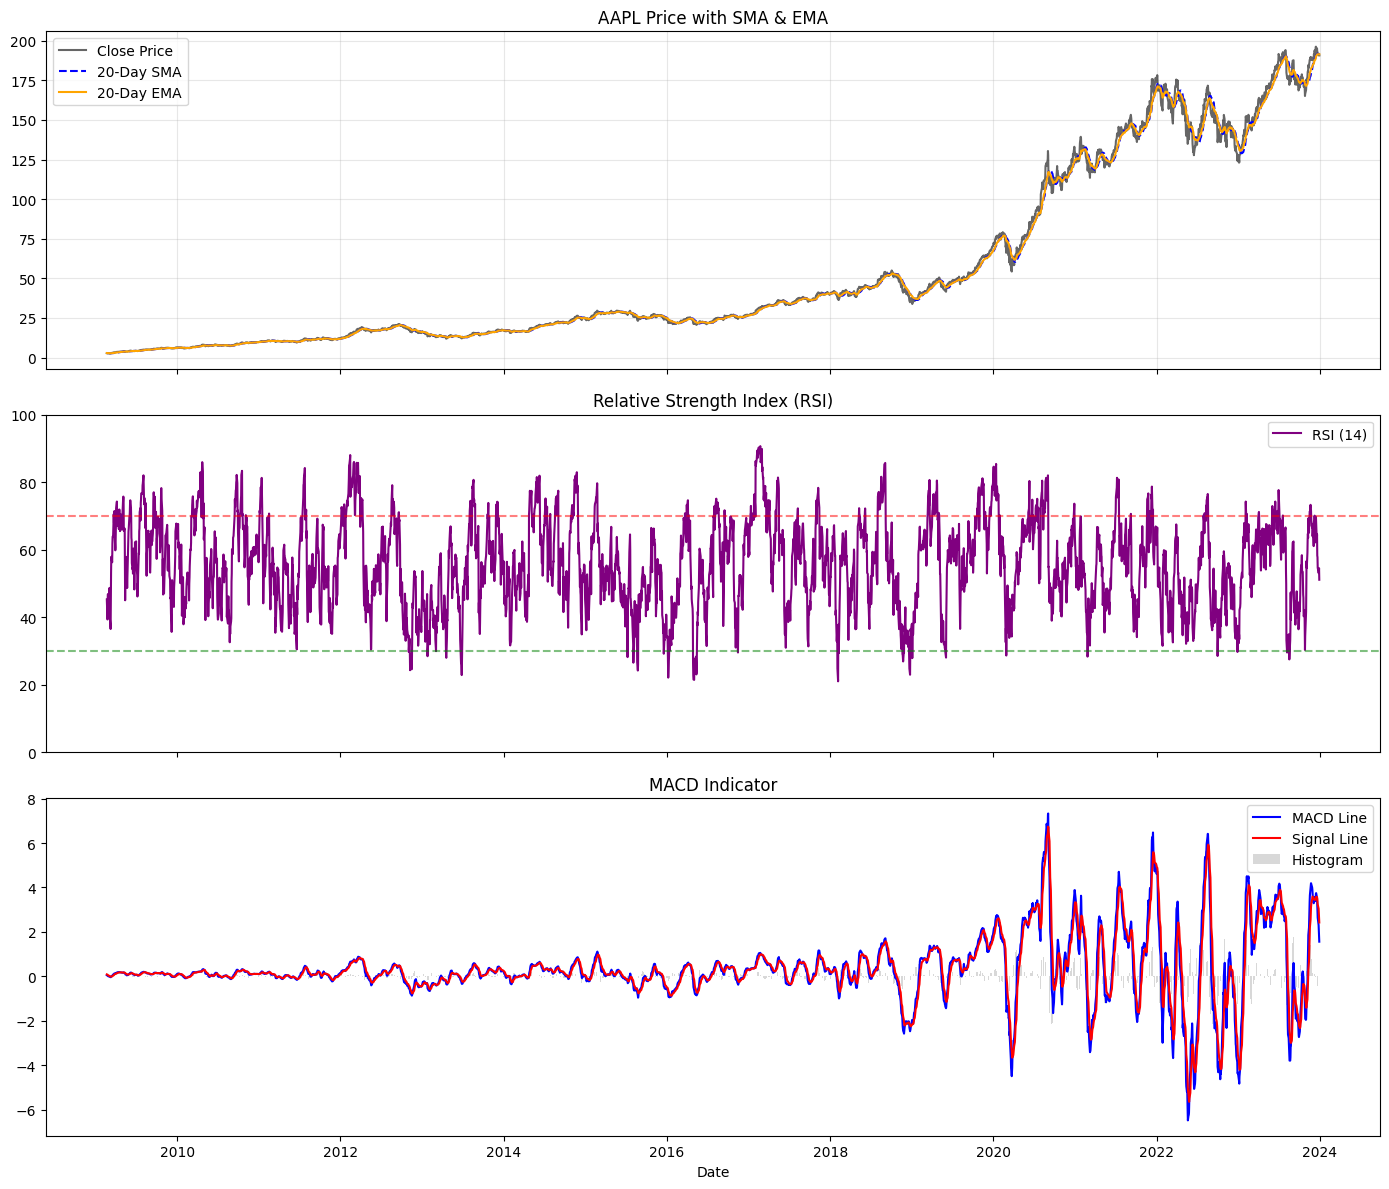

In [8]:
# Create a figure with 3 stacked panels sharing the same X-axis (Dates)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Panel 1: Price Action + Moving Averages
ax1.plot(df.index, df['Close'], label='Close Price', alpha=0.6, color='black')
ax1.plot(df.index, df['SMA_20'], label='20-Day SMA', color='blue', linestyle='--')
ax1.plot(df.index, df['EMA_20'], label='20-Day EMA', color='orange')
ax1.set_title('AAPL Price with SMA & EMA')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Panel 2: RSI Momentum
ax2.plot(df.index, df['RSI_14'], label='RSI (14)', color='purple')
ax2.axhline(70, color='red', linestyle='--', alpha=0.5)  # Overbought threshold
ax2.axhline(30, color='green', linestyle='--', alpha=0.5) # Oversold threshold
ax2.set_title('Relative Strength Index (RSI)')
ax2.set_ylim(0, 100)
ax2.legend(loc='best')

# Panel 3: MACD (Trend Momentum)
ax3.plot(df.index, df['MACD'], label='MACD Line', color='blue')
ax3.plot(df.index, df['MACD_signal'], label='Signal Line', color='red')
# Histogram shows the distance between MACD and Signal line
ax3.bar(df.index, df['MACD_hist'], label='Histogram', color='gray', alpha=0.3)
ax3.set_title('MACD Indicator')
ax3.legend(loc='best')

# Final formatting
plt.xlabel('Date')
plt.tight_layout()
plt.show()


1. Trend Analysis: Price vs. Moving Averages (Panel 1)The relationship between Apple’s price and its 20-day averages (SMA and EMA) reveals the immediate "health" of the stock:The Reaction Gap: Notice how the Orange EMA_20 stays closer to the price bars than the Blue SMA_20. Because Apple is a high-volume stock sensitive to news (product launches, earnings), the EMA is your "early warning system."Support/Resistance: If the price is consistently bouncing off the SMA_20 from above, it indicates a strong, healthy uptrend. If the price is "smothered" below both lines, Apple is in a short-term bearish phase.2. Momentum Analysis: Relative Strength Index (Panel 2)The RSI panel measures the speed and change of price movements to see if AAPL is "overheated":Overbought (>70): When Apple’s purple line enters the red dashed zone, it suggests that the buying frenzy may be exhausted. Historically, for AAPL, this often precedes a period of sideways trading or a minor "mean reversion" back to the SMA.Oversold (<30): If the line dips into the green zone, it indicates the stock is undervalued in the short term. For a stable giant like Apple, these are traditionally viewed as strong "buy the dip" windows.3. Trend Shifts: MACD Indicator (Panel 3)The MACD provides the "conviction" behind the price move:The Crossover Signal: When the Blue MACD line crosses above the Red Signal line, it creates a bullish signal. If the bars in the Gray Histogram are growing taller, it means the upward momentum is accelerating.Centerline Cross: If the MACD line moves from below 0 to above 0, it confirms that Apple has shifted from a long-term bearish state to a bullish one.4. Risk-Adjusted Performance: The Sharpe RatioYour code calculates the Sharpe Ratio for AAPL, which is the most critical metric for institutional investors:Interpretation: If your printed Sharpe Ratio is above 1.0, it means Apple is providing excellent returns relative to the volatility you have to endure.Comparison: Compared to Amazon (which you analyzed previously as having higher volatility), Apple typically maintains a "smoother" Sharpe Ratio, reflecting its status as a "Safe Haven" tech stock.